# Hotel price prediction

## Import the file and read it

In [62]:
import pandas as pd
import numpy as np
import os
import math

In [63]:
df = pd.read_csv("../../Merge/final_selected_data.csv", low_memory=False)
df

,room_type_id,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,...,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng,hotel_id,room_room_type_name,hotel_name,hotel_address,region
0,1,1,0,0,0,0,0,0,0,0,...,1,0,1,0,0,71897952,Phòng Deluxe Có Giường Cỡ King (Deluxe King Room),Nha Nghi Nhung - Nhung Motel,"73 Đoàn Thị Điểm, Bà Rịa, Bà Rịa, Việt Nam",Bà Rịa
1,2,0,1,0,0,0,0,0,0,0,...,1,0,1,0,0,49685029,Phòng Tiêu Chuẩn (Standard Room),Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),"KDC Baria City Gate, Long Huong Ward, Ba Ria C...",Bà Rịa
2,3,0,1,0,0,0,0,0,0,0,...,1,0,1,0,0,49685029,Phòng gia đình có ban công (Family Room with B...,Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),"KDC Baria City Gate, Long Huong Ward, Ba Ria C...",Bà Rịa
3,4,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,65481766,Phòng Có Giường Cỡ King Với Ban Công (King Roo...,Baly Hotel Bà Rịa City (Baly Hotel Ba Ria City),"QL51, Bà Rịa, Bà Rịa, Việt Nam",Bà Rịa
4,5,1,0,1,0,0,0,0,0,0,...,1,0,0,0,0,5808626,Phòng Studio Executive (Studio Executive),Citadines Central Bình Dương (Citadines Centra...,"Số 328C, Đại lộ B nh Dương, Khu phố Hưng Lộc, ...",Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19515,12043,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,80986701,Phòng Tiêu Chuẩn (Standard Room),Khách sạn Thu Trang (Hotel Thu Trang),"ngõ 63 Đ. Phạm Hùng, Lưỡng Vượng, Hotel thu tr...",Tuyên Quang
19516,12044,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,80986701,Deluxe - 1 Bedroom Apartment Magnificent views,Khách sạn Thu Trang (Hotel Thu Trang),"ngõ 63 Đ. Phạm Hùng, Lưỡng Vượng, Hotel thu tr...",Tuyên Quang
19517,12045,0,0,0,0,1,0,0,0,0,...,1,0,1,0,0,80986701,Deluxe giường đôi hoặc 2 giường (Deluxe Double...,Khách sạn Thu Trang (Hotel Thu Trang),"ngõ 63 Đ. Phạm Hùng, Lưỡng Vượng, Hotel thu tr...",Tuyên Quang
19518,12046,1,0,0,0,0,0,0,0,0,...,1,0,1,0,0,81051270,Phòng Gia Đình (Family Room),Hotel Thu Trang,Hotel thu trang số 11 ngõ 63 đường phạm hùng p...,Tuyên Quang


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19520 entries, 0 to 19519
Data columns (total 51 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   room_type_id                  19520 non-null  int64  
 1   large_double_bed              19520 non-null  int64  
 2   large_bed                     19520 non-null  int64  
 3   single_bed                    19520 non-null  int64  
 4   sofa_bed                      19520 non-null  int64  
 5   double_bed                    19520 non-null  int64  
 6   small_double_bed              19520 non-null  int64  
 7   king_size_bed                 19520 non-null  int64  
 8   futon_mattress                19520 non-null  int64  
 9   bunk_bed                      19520 non-null  int64  
 10  flexibility_score             19520 non-null  int64  
 11  sqm                           18054 non-null  float64
 12  bathroom_count                19520 non-null  int64  
 13  i

In [65]:
df.shape

(19520, 51)

In [66]:
df.drop(columns=["room_type_id","hotel_id","hotel_address"], inplace=True)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19520 entries, 0 to 19519
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   large_double_bed              19520 non-null  int64  
 1   large_bed                     19520 non-null  int64  
 2   single_bed                    19520 non-null  int64  
 3   sofa_bed                      19520 non-null  int64  
 4   double_bed                    19520 non-null  int64  
 5   small_double_bed              19520 non-null  int64  
 6   king_size_bed                 19520 non-null  int64  
 7   futon_mattress                19520 non-null  int64  
 8   bunk_bed                      19520 non-null  int64  
 9   flexibility_score             19520 non-null  int64  
 10  sqm                           18054 non-null  float64
 11  bathroom_count                19520 non-null  int64  
 12  is_private_bathroom           19520 non-null  int64  
 13  v

In [68]:
df

,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,flexibility_score,...,bãi_đậu_xe,phòng_tập,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng,room_room_type_name,hotel_name,region
0,1,0,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng Deluxe Có Giường Cỡ King (Deluxe King Room),Nha Nghi Nhung - Nhung Motel,Bà Rịa
1,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng Tiêu Chuẩn (Standard Room),Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),Bà Rịa
2,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng gia đình có ban công (Family Room with B...,Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),Bà Rịa
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,Phòng Có Giường Cỡ King Với Ban Công (King Roo...,Baly Hotel Bà Rịa City (Baly Hotel Ba Ria City),Bà Rịa
4,1,0,1,0,0,0,0,0,0,2,...,0,0,1,0,0,0,0,Phòng Studio Executive (Studio Executive),Citadines Central Bình Dương (Citadines Centra...,Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19515,0,0,1,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng Tiêu Chuẩn (Standard Room),Khách sạn Thu Trang (Hotel Thu Trang),Tuyên Quang
19516,0,0,1,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Deluxe - 1 Bedroom Apartment Magnificent views,Khách sạn Thu Trang (Hotel Thu Trang),Tuyên Quang
19517,0,0,0,0,1,0,0,0,0,2,...,1,0,1,0,1,0,0,Deluxe giường đôi hoặc 2 giường (Deluxe Double...,Khách sạn Thu Trang (Hotel Thu Trang),Tuyên Quang
19518,1,0,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Phòng Gia Đình (Family Room),Hotel Thu Trang,Tuyên Quang


In [69]:
df.describe()

,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,flexibility_score,...,price_option_price,adults_number,children_number,bãi_đậu_xe,phòng_tập,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng
count,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,...,1.949100e+04,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000
mean,0.363832,0.245389,0.227203,0.053535,0.240369,0.011373,0.025615,0.010553,0.013678,1.050820,...,1.567054e+06,2.473412,0.466035,0.650973,0.105123,0.734682,0.218699,0.414652,0.030482,0.177459
std,0.481113,0.430329,0.419035,0.225103,0.427318,0.106039,0.157987,0.102188,0.116155,0.224252,...,5.910918e+06,1.753879,0.720954,0.476675,0.306720,0.441513,0.413374,0.492674,0.171913,0.382066
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,4.335440e+05,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,7.352940e+05,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.396832e+06,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,...,6.666667e+08,50.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [70]:
df.shape

(19520, 48)

In [71]:
df.isna().sum()

large_double_bed                   0
large_bed                          0
single_bed                         0
sofa_bed                           0
double_bed                         0
small_double_bed                   0
king_size_bed                      0
futon_mattress                     0
bunk_bed                           0
flexibility_score                  0
sqm                             1466
bathroom_count                     0
is_private_bathroom                0
views                              0
balcony-terrace                    0
closet                             0
air_conditioning                   0
hair_dryer                         0
complimentary-bottled-water        0
bathtub                            0
shower                             0
refrigerator                       0
high-floor                         0
dressing-room                      0
ground-floor                       0
private-pool                       0
top-floor                          0
c

In [72]:
df = df.dropna(subset=['price_option_price'])

In [73]:
df = df.dropna(subset=['sqm'])

In [74]:
df.isna().sum()

large_double_bed                0
large_bed                       0
single_bed                      0
sofa_bed                        0
double_bed                      0
small_double_bed                0
king_size_bed                   0
futon_mattress                  0
bunk_bed                        0
flexibility_score               0
sqm                             0
bathroom_count                  0
is_private_bathroom             0
views                           0
balcony-terrace                 0
closet                          0
air_conditioning                0
hair_dryer                      0
complimentary-bottled-water     0
bathtub                         0
shower                          0
refrigerator                    0
high-floor                      0
dressing-room                   0
ground-floor                    0
private-pool                    0
top-floor                       0
complimentary-instant-coffee    0
electric-blanket                0
free-welcome-d

In [75]:
df.shape

(18026, 48)

In [76]:
df.duplicated().sum()

np.int64(86)

In [77]:
df = df.drop_duplicates()

In [78]:
df.shape

(17940, 48)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17940 entries, 0 to 19519
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   large_double_bed              17940 non-null  int64  
 1   large_bed                     17940 non-null  int64  
 2   single_bed                    17940 non-null  int64  
 3   sofa_bed                      17940 non-null  int64  
 4   double_bed                    17940 non-null  int64  
 5   small_double_bed              17940 non-null  int64  
 6   king_size_bed                 17940 non-null  int64  
 7   futon_mattress                17940 non-null  int64  
 8   bunk_bed                      17940 non-null  int64  
 9   flexibility_score             17940 non-null  int64  
 10  sqm                           17940 non-null  float64
 11  bathroom_count                17940 non-null  int64  
 12  is_private_bathroom           17940 non-null  int64  
 13  views 

## Modeling

### Linear Models (Linear/ Ridge/ Lasso)

In this section, we build **baseline linear regression models** to predict room prices.

**Why Linear Models?**
- Simple, fast, and interpretable
- A strong baseline to compare with more advanced models (e.g., tree-based models)

**Key preprocessing decisions**
- **Target transformation:** we predict `log_price` instead of raw `price_option_price` to reduce strong skewness and reduce the impact of extreme outliers.
- **Drop high-cardinality features:** `hotel_name` and `room_room_type_name` were removed because one-hot encoding them would create too many sparse features and may cause overfitting.
- **Categorical encoding:** `views` and `region` will be one-hot encoded.
- **Scaling numeric variables:** continuous numeric features will be scaled using `RobustScaler` (more stable when outliers exist).
- **Binary amenities:** kept as-is (0/1), no scaling required.

**Models to train**
- Linear Regression
- Ridge Regression (L2 Regularization)
- Lasso Regression (L1 Regularization)

In [80]:
df['log_price'] = np.log1p(df['price_option_price'])

In [81]:
threshold = 2_000_000

df_cheap = df[df["price_option_price"] < threshold].copy()
df_rich  = df[df["price_option_price"] >= threshold].copy()

print("Full df:", df.shape)
print("df_cheap:", df_cheap.shape, "| ratio:", round(len(df_cheap)/len(df)*100, 2), "%")
print("df_rich :", df_rich.shape,  "| ratio:", round(len(df_rich)/len(df)*100, 2), "%")

Full df: (17940, 49)
df_cheap: (15080, 49) | ratio: 84.06 %
df_rich : (2860, 49) | ratio: 15.94 %


In [82]:
df2= df_cheap.copy()

In [83]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15080 entries, 0 to 19519
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   large_double_bed              15080 non-null  int64  
 1   large_bed                     15080 non-null  int64  
 2   single_bed                    15080 non-null  int64  
 3   sofa_bed                      15080 non-null  int64  
 4   double_bed                    15080 non-null  int64  
 5   small_double_bed              15080 non-null  int64  
 6   king_size_bed                 15080 non-null  int64  
 7   futon_mattress                15080 non-null  int64  
 8   bunk_bed                      15080 non-null  int64  
 9   flexibility_score             15080 non-null  int64  
 10  sqm                           15080 non-null  float64
 11  bathroom_count                15080 non-null  int64  
 12  is_private_bathroom           15080 non-null  int64  
 13  views 

In [84]:
df2.shape

(15080, 49)

In [85]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15080 entries, 0 to 19519
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   large_double_bed              15080 non-null  int64  
 1   large_bed                     15080 non-null  int64  
 2   single_bed                    15080 non-null  int64  
 3   sofa_bed                      15080 non-null  int64  
 4   double_bed                    15080 non-null  int64  
 5   small_double_bed              15080 non-null  int64  
 6   king_size_bed                 15080 non-null  int64  
 7   futon_mattress                15080 non-null  int64  
 8   bunk_bed                      15080 non-null  int64  
 9   flexibility_score             15080 non-null  int64  
 10  sqm                           15080 non-null  float64
 11  bathroom_count                15080 non-null  int64  
 12  is_private_bathroom           15080 non-null  int64  
 13  views 

In [86]:
df2.drop(columns=["room_room_type_name","hotel_name","price_option_price"], inplace=True)

Before training linear models, we must carefully preprocess features because:

- Some numerical features contain **extreme outliers** (especially `sqm`)
- Linear/Ridge/Lasso are sensitive to feature scale
- Categorical features must be encoded

**Outlier handling**
From EDA, `sqm` has very large values (up to thousands), which can strongly distort linear models.

We apply:
- **log1p transformation** for `sqm` → `sqm_log = log(1 + sqm)`

This reduces skewness and compresses extreme values while keeping ordering.

**Scaling (Normalization)**
For Ridge/Lasso, scaling is important because regularization depends on coefficient magnitude.

We scale only continuous numeric features:
- `sqm_log`
- `bathroom_count`
- `bedroom_count`
- `adults_number`
- `children_number`
- `flexibility_score`

Binary features (0/1) are not scaled.

**Encoding categorical features**
- `views`
- `region`

We use OneHotEncoder(handle_unknown="ignore") to avoid errors for unseen categories in test data.

In [87]:
import numpy as np
import pandas as pd

# Copy dataset to avoid modifying original df2
df_linear = df2.copy()

# Apply log1p transform to sqm, price (outlier handling)
df_linear["sqm_log"] = np.log1p(df_linear["sqm"])


# Drop original sqm
df_linear.drop(columns=["sqm"], inplace=True)

df_linear.head()

,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,flexibility_score,...,bãi_đậu_xe,phòng_tập,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng,region,log_price,sqm_log
0,1,0,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Bà Rịa,12.575990,2.944439
1,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Bà Rịa,12.796943,3.433987
2,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,0,0,Bà Rịa,13.307769,3.828641
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,Bà Rịa,12.962023,3.044522
4,1,0,1,0,0,0,0,0,0,2,...,0,0,1,0,0,0,0,Bình Dương,14.187075,3.583519


**Train/Test Split Strategy**

We split the dataset into:
- **80% training**
- **20% testing**

We use:
- random_state=42 for reproducibility

Because `log_price` is continuous (regression), we cannot directly stratify like classification.
However, we can still **check the distribution** of key variables after splitting to ensure train/test are similar.


In [88]:
from sklearn.model_selection import train_test_split

X = df_linear.drop(columns=["log_price"])
y = df_linear["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (12064, 45)
Test shape : (3016, 45)


****Check Train vs Test Balance

Even though regression does not use stratification, we must verify that train/test sets have similar distributions.

We check:
- Target distribution (`log_price`)  
- Important numerical features (`sqm_log`, counts)  
- Categorical frequency (`views`, `region`)

If train/test distributions look similar, the split is valid.


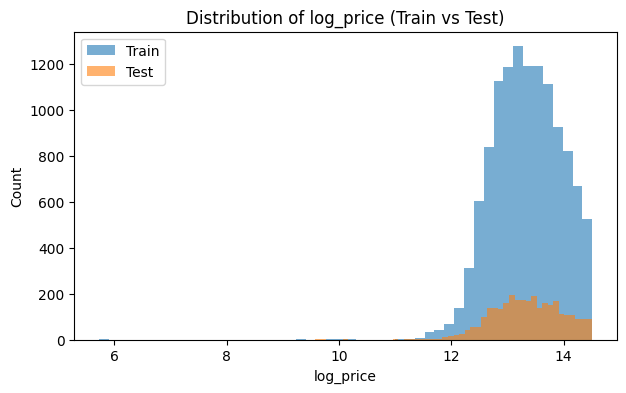

Train log_price mean: 13.340526919347246
Test log_price mean : 13.357849005772023


In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(y_train, bins=50, alpha=0.6, label="Train")
plt.hist(y_test, bins=50, alpha=0.6, label="Test")
plt.title("Distribution of log_price (Train vs Test)")
plt.xlabel("log_price")
plt.ylabel("Count")
plt.legend()
plt.show()

print("Train log_price mean:", y_train.mean())
print("Test log_price mean :", y_test.mean())

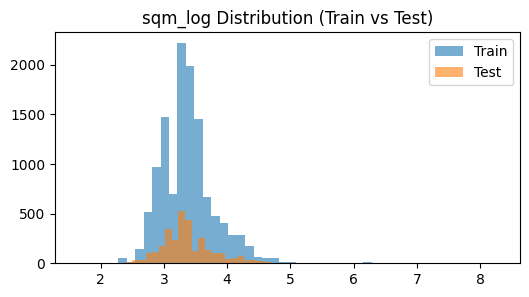

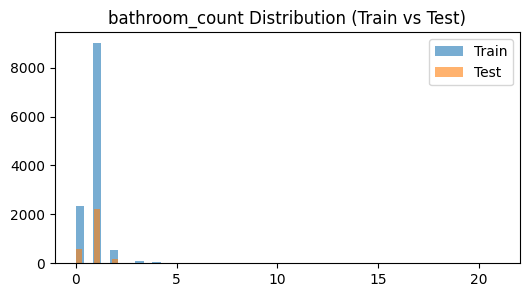

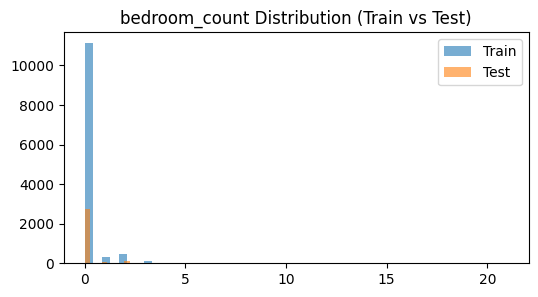

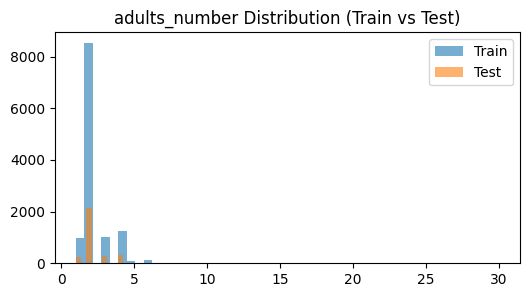

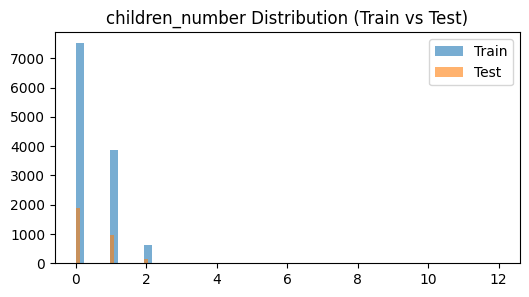

In [90]:
num_check = ["sqm_log", "bathroom_count", "bedroom_count", "adults_number", "children_number"]

for col in num_check:
    plt.figure(figsize=(6,3))
    plt.hist(X_train[col], bins=50, alpha=0.6, label="Train")
    plt.hist(X_test[col], bins=50, alpha=0.6, label="Test")
    plt.title(f"{col} Distribution (Train vs Test)")
    plt.legend()
    plt.show()

In [91]:
# Compare views distribution
views_train = X_train["views"].value_counts(normalize=True)
views_test  = X_test["views"].value_counts(normalize=True)

compare_views = pd.concat([views_train, views_test], axis=1)
compare_views.columns = ["train_ratio", "test_ratio"]
compare_views["diff"] = (compare_views["train_ratio"] - compare_views["test_ratio"]).abs()

compare_views.sort_values("diff", ascending=False)

,train_ratio,test_ratio,diff
views,,,
city,0.267076,0.278846,0.011771
nature,0.224138,0.214523,0.009615
lake,0.015086,0.019894,0.004808
no view,0.285146,0.280504,0.004642
sea,0.082062,0.077586,0.004476
pool,0.012848,0.015915,0.003067
garden,0.113644,0.112732,0.000912


In [92]:
# Compare region distribution
views_train = X_train["region"].value_counts(normalize=True)
views_test  = X_test["region"].value_counts(normalize=True)

compare_views = pd.concat([views_train, views_test], axis=1)
compare_views.columns = ["train_ratio", "test_ratio"]
compare_views["diff"] = (compare_views["train_ratio"] - compare_views["test_ratio"]).abs()

compare_views.sort_values("diff", ascending=False)

,train_ratio,test_ratio,diff
region,,,
Ninh Bình,0.093584,0.079907,0.013677
Hải Phòng,0.065235,0.074602,0.009367
Bình Định,0.093336,0.084549,0.008786
Thừa Thiên Huế,0.081316,0.073276,0.008040
Đà Nẵng,0.150779,0.158488,0.007709
Hà Nội,0.097812,0.103448,0.005637
Bình Dương,0.033985,0.039125,0.005139
Nghệ An,0.016495,0.020889,0.004393
Kiên Giang,0.006300,0.003647,0.002653


"Train/test distributions were checked for the target and key variables; both sets show highly similar distributions and close mean values, indicating a representative and unbiased split."

**Preprocessing Pipeline for Linear Models**

We use a ColumnTransformer:

- Categorical features → OneHotEncoding
- Numerical features → RobustScaler
- Binary features → passthrough (unchanged)

This ensures no data leakage and consistent transformations.


In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline

cat_features = ["views", "region"]

num_features = [
    "sqm_log",
    "bathroom_count",
    "bedroom_count",
    "adults_number",
    "children_number",
    "flexibility_score"
]

binary_features = [c for c in X.columns if c not in cat_features + num_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", RobustScaler(), num_features),
        ("bin", "passthrough", binary_features)
    ]
)

**Train Linear / Ridge / Lasso**

We train three baseline linear models:

- **Linear Regression**
- **Ridge Regression** (L2 regularization)
- **Lasso Regression** (L1 regularization)

We evaluate using:
- MAE
- RMSE
- R² score

In [94]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"--- {name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}\n")

    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=5000)
}

results = []

for name, reg in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", reg)
    ])

    pipe.fit(X_train, y_train)
    results.append(evaluate_model(name, pipe, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

--- LinearRegression ---
MAE  : 0.3568
RMSE : 0.4626
R²   : 0.4231

--- Ridge ---
MAE  : 0.3568
RMSE : 0.4626
R²   : 0.4233

--- Lasso ---
MAE  : 0.3606
RMSE : 0.4672
R²   : 0.4116



,model,MAE,RMSE,R2
1,Ridge,0.356778,0.462579,0.423276
0,LinearRegression,0.356814,0.462636,0.423133
2,Lasso,0.360645,0.467227,0.411629


Ridge achieves the best performance among linear models (RMSE ≈ 0.61, R² ≈ 0.546). Linear Regression performs similarly, while Lasso slightly underperforms due to feature shrinkage. Overall, linear models provide a solid baseline but are limited in capturing non-linear relationships and complex interactions.

In [95]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_original_price(model, X_test, y_test_log):
    # predict log_price
    pred_log = model.predict(X_test)

    # convert to original price scale
    pred_price = np.expm1(pred_log)
    true_price = np.expm1(y_test_log)

    # compute errors in VND
    mae = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))

    print("MAE (VND):", f"{mae:,.0f}")
    print("RMSE (VND):", f"{rmse:,.0f}")

    return mae, rmse

In [96]:
ridge_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0, random_state=42))
])

ridge_model.fit(X_train, y_train)

evaluate_original_price(ridge_model, X_test, y_test)

MAE (VND): 254,512
RMSE (VND): 359,190


(254512.47089089925, np.float64(359189.7573339137))

### Tree base model (Random Forest/ XGBoost/ LightGBM/ CatBoost)

In [97]:
df2

,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,flexibility_score,...,children_number,bãi_đậu_xe,phòng_tập,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng,region,log_price
0,1,0,0,0,0,0,0,0,0,1,...,0,1,0,1,0,1,0,0,Bà Rịa,12.575990
1,0,1,0,0,0,0,0,0,0,1,...,0,1,0,1,0,1,0,0,Bà Rịa,12.796943
2,0,1,0,0,0,0,0,0,0,1,...,2,1,0,1,0,1,0,0,Bà Rịa,13.307769
3,0,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0,Bà Rịa,12.962023
4,1,0,1,0,0,0,0,0,0,2,...,0,0,0,1,0,0,0,0,Bình Dương,14.187075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19515,0,0,1,0,0,0,0,0,0,1,...,0,1,0,1,0,1,0,0,Tuyên Quang,12.303830
19516,0,0,1,0,0,0,0,0,0,1,...,0,1,0,1,0,1,0,0,Tuyên Quang,12.509457
19517,0,0,0,0,1,0,0,0,0,2,...,0,1,0,1,0,1,0,0,Tuyên Quang,12.519386
19518,1,0,0,0,0,0,0,0,0,1,...,0,1,0,1,0,1,0,0,Tuyên Quang,12.219502


In [98]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15080 entries, 0 to 19519
Data columns (total 46 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   large_double_bed              15080 non-null  int64  
 1   large_bed                     15080 non-null  int64  
 2   single_bed                    15080 non-null  int64  
 3   sofa_bed                      15080 non-null  int64  
 4   double_bed                    15080 non-null  int64  
 5   small_double_bed              15080 non-null  int64  
 6   king_size_bed                 15080 non-null  int64  
 7   futon_mattress                15080 non-null  int64  
 8   bunk_bed                      15080 non-null  int64  
 9   flexibility_score             15080 non-null  int64  
 10  sqm                           15080 non-null  float64
 11  bathroom_count                15080 non-null  int64  
 12  is_private_bathroom           15080 non-null  int64  
 13  views 

In this section, we train **tree-based regression models**

Tree-based models are usually stronger than linear models for price prediction because they can capture:
- non-linear relationships (e.g., sqm vs price)
- interactions between features (e.g., region × room capacity)
- sparse binary amenities better
- heavy-tailed price patterns (even after log transform)

**Models to train**
- **Random Forest Regressor** (baseline)
- **Gradient Boosting Models** (optional extension):
  - XGBoost
  - LightGBM
  - CatBoost

**Preprocessing notes**
**Tree models**: **do not need scaling (normalization)**  
But we still need to encode categorical columns:
- `views`
- `region`

Binary and numerical features remain unchanged.

Target variable is:
- `log_price`


In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

We separate:
- **X** = all features (excluding `log_price`)
- **y** = `log_price`

We also apply an optional transformation:
- log1p(sqm) → reduces extreme outliers and helps tree models split better.


In [100]:
df_tree = df2.copy()

# handle sqm outliers using log1p
df_tree["sqm_log"] = np.log1p(df_tree["sqm"])
df_tree.drop(columns=["sqm"], inplace=True)

X = df_tree.drop(columns=["log_price"])
y = df_tree["log_price"]

In [101]:
X.shape

(15080, 45)

In [102]:
y.shape

(15080,)

We split the data into:
- 80% training
- 20% testing

We keep random_state=42 for reproducibility.


In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (12064, 45)
Test shape : (3016, 45)


Before training tree-based models, we verify that the train/test split is **representative**.

We check:
- Target distribution (`log_price`)
- Key numerical features (`sqm_log`, counts)
- Categorical distributions (`views`, `region`)

A good split should show similar distributions between train and test,
avoiding sampling bias and ensuring fair evaluation.


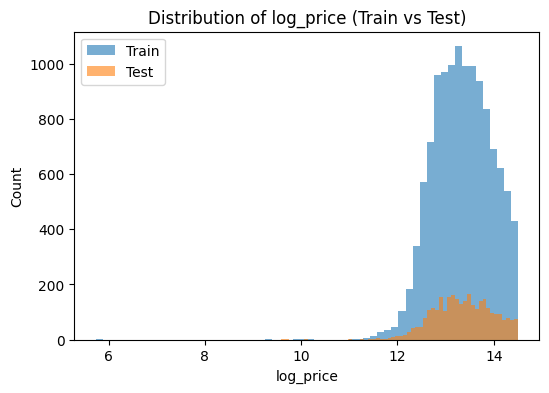

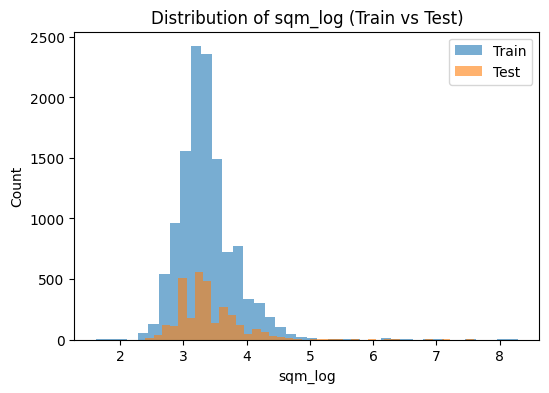

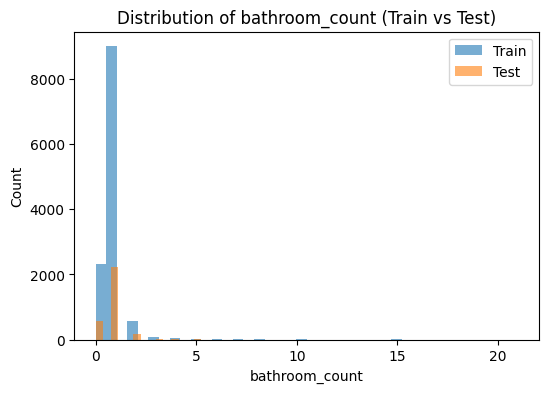

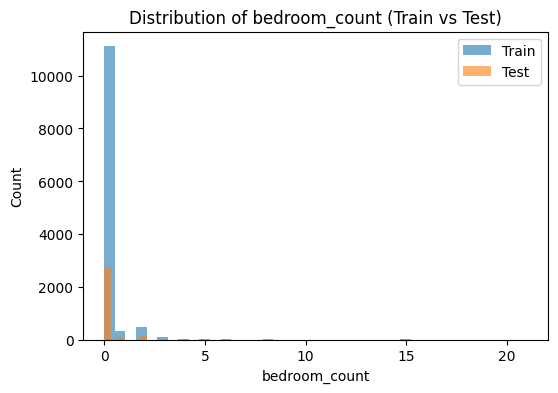

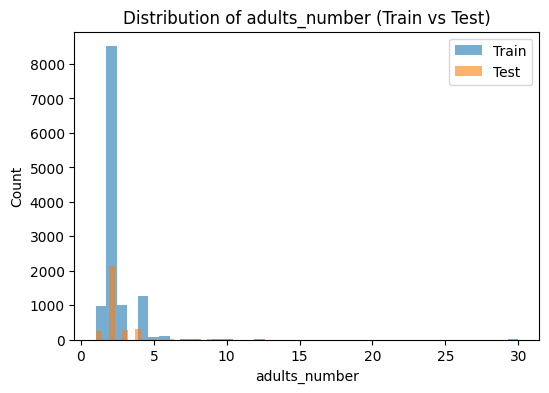

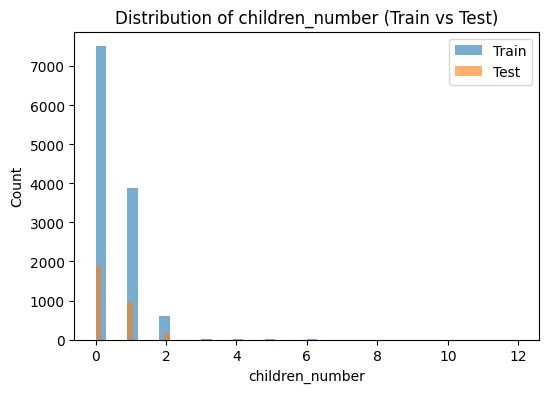

Train log_price mean: 13.340526919347246
Test log_price mean : 13.357849005772023


In [104]:
import matplotlib.pyplot as plt

def plot_train_test_distribution(train, test, feature, bins=50):
    plt.figure(figsize=(6,4))
    plt.hist(train[feature], bins=bins, alpha=0.6, label="Train")
    plt.hist(test[feature], bins=bins, alpha=0.6, label="Test")
    plt.title(f"Distribution of {feature} (Train vs Test)")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

# create helper dataframes for plotting
train_df = X_train.copy()
train_df["log_price"] = y_train

test_df = X_test.copy()
test_df["log_price"] = y_test

# target distribution
plot_train_test_distribution(train_df, test_df, "log_price", bins=60)

# key numerical features
for col in ["sqm_log", "bathroom_count", "bedroom_count", "adults_number", "children_number"]:
    plot_train_test_distribution(train_df, test_df, col, bins=40)

print("Train log_price mean:", y_train.mean())
print("Test log_price mean :", y_test.mean())

In [105]:
def compare_category_ratio(train_series, test_series, top_n=15):
    train_ratio = train_series.value_counts(normalize=True)
    test_ratio = test_series.value_counts(normalize=True)

    compare_df = pd.DataFrame({
        "train_ratio": train_ratio,
        "test_ratio": test_ratio
    }).fillna(0)

    compare_df["diff"] = (compare_df["train_ratio"] - compare_df["test_ratio"]).abs()

    return compare_df.sort_values("diff", ascending=False).head(top_n)

# views balance
views_balance = compare_category_ratio(X_train["views"], X_test["views"], top_n=10)
views_balance

,train_ratio,test_ratio,diff
views,,,
city,0.267076,0.278846,0.011771
nature,0.224138,0.214523,0.009615
lake,0.015086,0.019894,0.004808
no view,0.285146,0.280504,0.004642
sea,0.082062,0.077586,0.004476
pool,0.012848,0.015915,0.003067
garden,0.113644,0.112732,0.000912


Tree-based models do not need scaling.

We only apply:
- OneHotEncoding for categorical features: `views`, `region`
- All numerical + binary features → passthrough (unchanged)

This prevents leakage because the encoder is fitted only on training data inside the pipeline.


In [106]:
cat_features = ["views", "region"]

# numeric features in this dataset
num_features = [
    "sqm_log",
    "bathroom_count",
    "bedroom_count",
    "adults_number",
    "children_number",
    "flexibility_score"
]

binary_features = [c for c in X.columns if c not in cat_features + num_features]

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features),
        ("bin", "passthrough", binary_features)
    ]
)

We evaluate models using:
- **MAE**
- **RMSE**
- **R² score**

Metrics are computed on `log_price` scale (same as linear modeling).


In [107]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"--- {name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}\n")

    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

Random Forest is a strong baseline tree ensemble model.
It reduces variance by averaging predictions from many decision trees.

We start with:
- n_estimators = 300
- random_state = 42
- n_jobs = -1 (use all CPU cores)

In [108]:
rf_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_results = evaluate_model("RandomForest", rf_model, X_test, y_test)
rf_results

--- RandomForest ---
MAE  : 0.2531
RMSE : 0.3538
R²   : 0.6627



{'model': 'RandomForest',
 'MAE': 0.25310998028247433,
 'RMSE': np.float64(0.35377991025354333),
 'R2': 0.6626642544920288}

After training RandomForest, we continue with **gradient boosting models**.

Boosting models usually outperform RandomForest because they:
- build trees sequentially to correct previous errors
- handle non-linear patterns very well
- capture complex interactions between features
- often achieve better generalization with fewer trees

We evaluate:
- XGBoost Regressor
- LightGBM Regressor
- CatBoost Regressor

All models are trained using the same preprocessing pipeline:
- OneHotEncoder for categorical features (`views`, `region`)
- passthrough for numerical + binary features
- target = `log_price`


In [109]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

XGBoost is one of the most powerful boosting libraries and performs well on structured/tabular datasets.

We use:
- n_estimators = 500
- learning_rate = 0.05
- max_depth = 6
- subsample & colsample_bytree to reduce overfitting

In [110]:
xgb_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model("XGBoost", xgb_model, X_test, y_test)
xgb_results

--- XGBoost ---
MAE  : 0.2781
RMSE : 0.3659
R²   : 0.6391



{'model': 'XGBoost',
 'MAE': 0.27805503656979197,
 'RMSE': np.float64(0.3659034894568965),
 'R2': 0.6391479882849846}

LightGBM is optimized for speed and efficiency.
It often performs extremely well on large datasets with high-dimensional sparse features (such as OneHotEncoded features).

We use:
- n_estimators = 1000
- learning_rate = 0.05
- num_leaves controls complexity
- subsample/colsample to regularize

In [111]:
lgbm_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_model.fit(X_train, y_train)

lgbm_results = evaluate_model("LightGBM", lgbm_model, X_test, y_test)
lgbm_results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 315
[LightGBM] [Info] Number of data points in the train set: 12064, number of used features: 87
[LightGBM] [Info] Start training from score 13.340527
--- LightGBM ---
MAE  : 0.2530
RMSE : 0.3429
R²   : 0.6831



C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'model': 'LightGBM',
 'MAE': 0.2530329428652047,
 'RMSE': np.float64(0.3428835248056755),
 'R2': 0.6831240600868255}

CatBoost is strong on datasets with categorical features.
It also performs well even without heavy preprocessing.

In our pipeline we still use OneHotEncoding for consistency.

We train:
- iterations = 1000
- learning_rate = 0.05
- depth = 8
- verbose = 0 (silent training)

In [112]:
cat_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=8,
        random_state=42,
        verbose=0
    ))
])

cat_model.fit(X_train, y_train)

cat_results = evaluate_model("CatBoost", cat_model, X_test, y_test)
cat_results

--- CatBoost ---
MAE  : 0.2737
RMSE : 0.3600
R²   : 0.6507



{'model': 'CatBoost',
 'MAE': 0.2736908193767625,
 'RMSE': np.float64(0.35997387705499145),
 'R2': 0.650748725507219}

We summarize the performance of:
- RandomForest
- XGBoost
- LightGBM
- CatBoost

and select the best model based on RMSE and R² score.

In [113]:
tree_results_df = pd.DataFrame([
    rf_results,
    xgb_results,
    lgbm_results,
    cat_results
]).sort_values("RMSE")

tree_results_df

,model,MAE,RMSE,R2
2,LightGBM,0.253033,0.342884,0.683124
0,RandomForest,0.253110,0.353780,0.662664
3,CatBoost,0.273691,0.359974,0.650749
1,XGBoost,0.278055,0.365903,0.639148


RandomForest achieved the best performance (RMSE = 0.4274, R² = 0.7769), outperforming boosting models in this baseline setting.
LightGBM performed competitively and may surpass RandomForest with hyperparameter tuning.
CatBoost and XGBoost produced lower performance, likely due to limited tuning and the sparse one-hot encoded feature space.

In [114]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_original_price(model, X_test, y_test_log):
    # predict on log scale
    pred_log = model.predict(X_test)

    # convert back to price (VND)
    pred_price = np.expm1(pred_log)
    true_price = np.expm1(y_test_log)

    # metrics in VND
    mae = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))

    print("MAE (VND):", f"{mae:,.0f}")
    print("RMSE (VND):", f"{rmse:,.0f}")

    return mae, rmse

In [115]:
evaluate_original_price(rf_model, X_test, y_test)

MAE (VND): 178,873
RMSE (VND): 269,561


(178873.10661278237, np.float64(269561.29539024475))


## Save trained pipelines for reuse
After training/evaluating, save the fitted pipelines (preprocessing + model) so they can be loaded later without retraining. Files are written under `notebook/Main/Khoa/models/` with names prefixed by `Khoa-Cheap` to keep each notebook separate.


In [ ]:

import joblib
import pathlib

models_dir = pathlib.Path('notebook/Main/Khoa/models')
models_dir.mkdir(parents=True, exist_ok=True)

# Persist the fitted pipelines; comment out any you don't need
# joblib.dump(rf_model, models_dir / 'Khoa-Cheap_rf.pkl')
# joblib.dump(xgb_model, models_dir / 'Khoa-Cheap_xgb.pkl')
# joblib.dump(lgbm_model, models_dir / 'Khoa-Cheap_lgbm.pkl')
# joblib.dump(cat_model, models_dir / 'Khoa-Cheap_cat.pkl')

print('Saved to:', models_dir)


Saved to: notebook\Main\Khoa\models


In [120]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_vnd(model, X_test, y_test_log):
    # Dự đoán log_price
    pred_log = model.predict(X_test)
    
    # Chuyển về giá gốc
    pred_price = np.expm1(pred_log)
    true_price = np.expm1(y_test_log)
    
    # MAE/RMSE thực tế
    mae = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    
    return mae, rmse

# Ví dụ với tất cả model cheap
vnd_results_cheap = []

for name, model in zip(all_results_cheap["model"], 
                       [ridge_model, rf_model, xgb_model, lgbm_model, cat_model]):
    mae, rmse = evaluate_vnd(model, X_test, y_test)
    r2 = all_results_cheap.loc[all_results_cheap["model"]==name, "R2"].values[0]
    vnd_results_cheap.append({"model": name, "MAE (VND)": mae, "RMSE (VND)": rmse, "R2": r2})

df_vnd_cheap = pd.DataFrame(vnd_results_cheap).sort_values("RMSE (VND)")
display(df_vnd_cheap)


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,MAE (VND),RMSE (VND),R2
3,XGBoost,180064.982066,267397.275669,0.639148
1,RandomForest,178873.106613,269561.295390,0.662664
4,Ridge,195743.889159,282663.458555,0.423276
2,CatBoost,199052.134843,285801.120304,0.650749
0,LightGBM,254512.470891,359189.757334,0.683124
